In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.decomposition import PCA

print("Environment ready")

Environment ready


In [26]:
#Pick ETFs

assets = {
    "SPY": "US large-cap stocks",
    "IWM": "US small-cap stocks",
    "EFA": "Developed-market stocks outside US and Canada",
    "EEM": "Emerging-market stocks",
    "IEF": "US Treasury bonds, 7–10 years",
    "TLT": "US Treasury bonds, 20+ years",
    "LQD": "Investment-grade corporate bonds",
    "HYG": "High-yield corporate bonds",
    "GLD": "Gold",
    "VNQ": "US real estate stocks",
}

tickers = list(assets.keys())

print(tickers)

['SPY', 'IWM', 'EFA', 'EEM', 'IEF', 'TLT', 'LQD', 'HYG', 'GLD', 'VNQ']


In [27]:
data = yf.download(
    tickers,
    start="2010-01-01",
    end="2026-01-01",
    auto_adjust=True,
)

prices = data["Close"].reindex(columns=tickers)

prices.head()

[*********************100%***********************]  10 of 10 completed


Ticker,SPY,IWM,EFA,EEM,IEF,TLT,LQD,HYG,GLD,VNQ
Date,,,,,,,,,,
2010-01-04,84.368980,51.111198,34.581219,30.194565,60.504974,54.849869,56.502274,33.738007,109.800003,23.145580
2010-01-05,84.592308,50.935467,34.611691,30.413725,60.770660,55.204132,56.772072,33.898060,109.699997,23.119600
2010-01-06,84.651878,50.887520,34.757984,30.477358,60.525402,54.465134,56.604774,33.985725,111.510002,23.078043
2010-01-07,85.009224,51.262997,34.623878,30.300608,60.525402,54.556774,56.674957,34.122913,110.820000,23.327412
2010-01-08,85.292099,51.542603,34.898193,30.540976,60.600380,54.532310,56.799065,34.176231,111.370003,23.155966


In [28]:
print("Rows and columns:", prices.shape)
print("\nMissing prices per ETF:")
print(prices.isna().sum())

Rows and columns: (4024, 10)

Missing prices per ETF:
Ticker
SPY    0
IWM    0
EFA    0
EEM    0
IEF    0
TLT    0
LQD    0
HYG    0
GLD    0
VNQ    0
dtype: int64


In [29]:
#Convert prices into daily simple returns 
returns = prices.pct_change(fill_method=None).iloc[1:]

display(returns.head())
print("Rows and columns:", returns.shape)

Ticker,SPY,IWM,EFA,EEM,IEF,TLT,LQD,HYG,GLD,VNQ
Date,,,,,,,,,,
2010-01-05,0.002647,-0.003438,0.000881,0.007258,0.004391,0.006459,0.004775,0.004744,-0.000911,-0.001122
2010-01-06,0.000704,-0.000941,0.004227,0.002092,-0.004036,-0.013387,-0.002947,0.002586,0.016500,-0.001797
2010-01-07,0.004221,0.007379,-0.003858,-0.005799,0.000000,0.001683,0.001240,0.004037,-0.006188,0.010805
2010-01-08,0.003328,0.005454,0.007923,0.007933,0.001239,-0.000448,0.002190,0.001563,0.004963,-0.007350
2010-01-11,0.001397,-0.004030,0.008210,-0.002083,0.000675,-0.005488,0.001046,-0.000892,0.013289,0.005833


Rows and columns: (4023, 10)


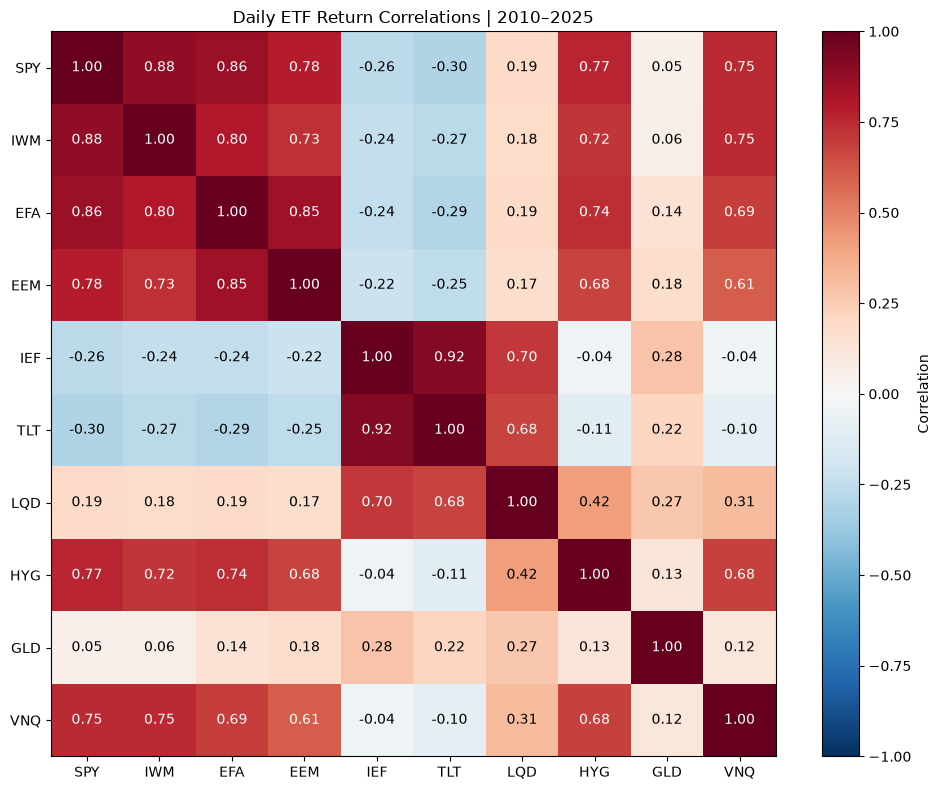

In [30]:
correlation = returns.corr()

fig, ax = plt.subplots(figsize=(10, 8))

heatmap = ax.imshow(
    correlation,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
)

ax.set_xticks(range(len(tickers)), labels=tickers)
ax.set_yticks(range(len(tickers)), labels=tickers)

for i in range(len(tickers)):
    for j in range(len(tickers)):
        value = correlation.iloc[i, j]
        ax.text(
            j, i, f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if abs(value) > 0.6 else "black",
        )

fig.colorbar(heatmap, ax=ax, label="Correlation")
ax.set_title("Daily ETF Return Correlations | 2010–2025")

plt.tight_layout()
plt.show()

In [31]:
print("SPY–IWM:", round(correlation.loc["SPY", "IWM"], 3))
print("SPY–TLT:", round(correlation.loc["SPY", "TLT"], 3))

SPY–IWM: 0.884
SPY–TLT: -0.298


In [32]:
#Standarize returns

return_means = returns.mean()
return_stds = returns.std()

standardized_returns = (returns - return_means) / return_stds

check = pd.DataFrame({
    "Mean": standardized_returns.mean(),
    "Standard deviation": standardized_returns.std(),
})

display(check.round(4))

,Mean,Standard deviation
Ticker,,
SPY,0.0,1.0
IWM,0.0,1.0
EFA,0.0,1.0
EEM,-0.0,1.0
IEF,0.0,1.0
TLT,-0.0,1.0
LQD,0.0,1.0
HYG,0.0,1.0
GLD,0.0,1.0


In [33]:
pca = PCA()
pca.fit(standardized_returns)

explained = pd.DataFrame({
    "Component": [f"PC{i}" for i in range(1, len(tickers) + 1)],
    "Variance explained (%)": 100 * pca.explained_variance_ratio_,
    "Cumulative (%)": 100 * np.cumsum(pca.explained_variance_ratio_),
})

display(explained.round(2))

,Component,Variance explained (%),Cumulative (%)
0,PC1,49.79,49.79
1,PC2,27.00,76.79
2,PC3,8.87,85.66
3,PC4,3.97,89.63
4,PC5,3.26,92.89
5,PC6,2.27,95.16
6,PC7,1.73,96.89
7,PC8,1.34,98.23
8,PC9,0.99,99.22
9,PC10,0.78,100.00


In [34]:
loadings = pd.DataFrame(
    pca.components_[:3].T,
    index=tickers,
    columns=["PC1", "PC2", "PC3"],
)

display(loadings.round(3))

,PC1,PC2,PC3
SPY,0.424,-0.020,-0.076
IWM,0.409,-0.013,-0.081
EFA,0.416,-0.009,0.068
EEM,0.391,-0.000,0.142
IEF,-0.117,0.561,-0.088
TLT,-0.140,0.544,-0.147
LQD,0.104,0.539,-0.174
HYG,0.380,0.130,-0.107
GLD,0.058,0.265,0.937
VNQ,0.368,0.106,-0.120


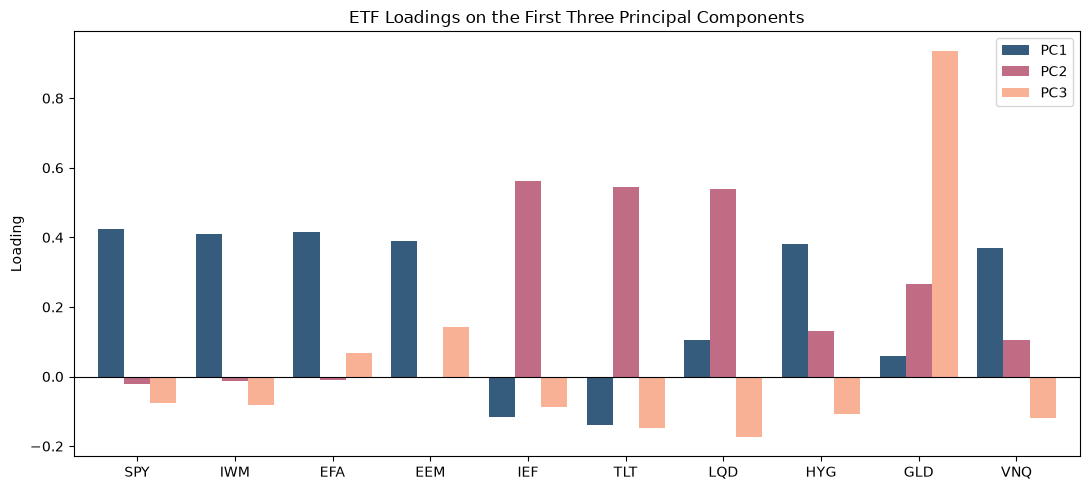

In [35]:
ax = loadings.plot.bar(
    figsize=(11, 5),
    width=0.8,
    color=["#355C7D", "#C06C84", "#F8B195"],
)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Loading")
ax.set_title("ETF Loadings on the First Three Principal Components")
ax.legend(title="")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
k = 3

# Shared risk from the first three components
directions = pca.components_[:k].T
factor_cov_std = (
    directions
    @ np.diag(pca.explained_variance_[:k])
    @ directions.T
)

# Risk left over for each individual ETF
scores = pca.transform(standardized_returns)[:, :k]
reconstructed = scores @ directions.T
residuals = standardized_returns.to_numpy() - reconstructed
residual_cov_std = np.diag(residuals.var(axis=0, ddof=1))

# Convert from standardized units back to daily-return units
scales = return_stds.to_numpy()
cov_pca = pd.DataFrame(
    (factor_cov_std + residual_cov_std) * np.outer(scales, scales),
    index=tickers,
    columns=tickers,
)

display(cov_pca.iloc[:5, :5].round(6))
print("Matrix shape:", cov_pca.shape)

,SPY,IWM,EFA,EEM,IEF
SPY,0.000118,0.000132,0.000110,0.000118,-0.000012
IWM,0.000132,0.000197,0.000137,0.000148,-0.000015
EFA,0.000110,0.000137,0.000134,0.000127,-0.000013
EEM,0.000118,0.000148,0.000127,0.000180,-0.000013
IEF,-0.000012,-0.000015,-0.000013,-0.000013,0.000017


Matrix shape: (10, 10)


In [37]:
from scipy.optimize import minimize

def min_variance_weights(covariance):
    cov = covariance.to_numpy() * 252  # Annualize for numerical scale
    n = len(cov)
    initial_weights = np.full(n, 1 / n)

    result = minimize(
        fun=lambda w: w @ cov @ w,
        x0=initial_weights,
        method="SLSQP",
        bounds=[(0, 1)] * n,
        constraints={"type": "eq", "fun": lambda w: w.sum() - 1},
        options={"ftol": 1e-12, "maxiter": 1000},
    )

    if not result.success:
        raise RuntimeError(result.message)

    return pd.Series(result.x, index=covariance.index)

weights_pca = min_variance_weights(cov_pca)

display((weights_pca * 100).round(2).rename("Portfolio weight (%)"))
print("Total weight:", round(weights_pca.sum(), 6))

SPY     0.62
IWM     0.00
EFA     0.00
EEM     0.00
IEF    60.82
TLT     0.00
LQD     0.00
HYG    37.76
GLD     0.80
VNQ     0.00
Name: Portfolio weight (%), dtype: float64

Total weight: 1.0


In [41]:
cov_sample = returns.cov().reindex(index=tickers, columns=tickers)
weights_sample = min_variance_weights(cov_sample)

weight_comparison = pd.DataFrame({
    "Equal weight": np.full(len(tickers), 1 / len(tickers)),
    "Sample covariance": weights_sample,
    "PCA covariance": weights_pca,
}, index=tickers)

display((100 * weight_comparison).round(2))

,Equal weight,Sample covariance,PCA covariance
SPY,10.0,1.16,0.62
IWM,10.0,0.00,0.00
EFA,10.0,0.00,0.00
EEM,10.0,0.00,0.00
IEF,10.0,61.06,60.82
TLT,10.0,0.00,0.00
LQD,10.0,0.00,0.00
HYG,10.0,37.24,37.76
GLD,10.0,0.54,0.80
VNQ,10.0,0.00,0.00


In [42]:
def pca_covariance(train_returns, n_components=3):
    means = train_returns.mean()
    stds = train_returns.std()
    standardized = (train_returns - means) / stds

    model = PCA(n_components=n_components)
    scores = model.fit_transform(standardized)

    directions = model.components_.T
    shared_cov = (
        directions
        @ np.diag(model.explained_variance_)
        @ directions.T
    )

    reconstructed = scores @ directions.T
    residuals = standardized.to_numpy() - reconstructed
    residual_cov = np.diag(residuals.var(axis=0, ddof=1))

    scales = stds.to_numpy()
    covariance = (shared_cov + residual_cov) * np.outer(scales, scales)

    return pd.DataFrame(
        covariance,
        index=train_returns.columns,
        columns=train_returns.columns,
    )

In [43]:
first_window = returns.iloc[:504]
first_pca_cov = pca_covariance(first_window)

print("Training dates:", first_window.index.min(), "to", first_window.index.max())
print("Covariance shape:", first_pca_cov.shape)
print("Missing values:", first_pca_cov.isna().sum().sum())

Training dates: 2010-01-05 00:00:00 to 2012-01-03 00:00:00
Covariance shape: (10, 10)
Missing values: 0


In [44]:
window_size = 504

months = returns.index.to_period("M")
month_starts = np.flatnonzero(
    np.r_[True, months[1:] != months[:-1]]
)

# Only use months with a complete training window
rebalance_starts = month_starts[month_starts >= window_size]

first_start = rebalance_starts[0]
next_start = rebalance_starts[1]

train = returns.iloc[first_start - window_size:first_start]
hold = returns.iloc[first_start:next_start]

print("Training:", train.index.min().date(), "to", train.index.max().date())
print("Evaluation:", hold.index.min().date(), "to", hold.index.max().date())
print("Training days:", len(train))
print("Evaluation days:", len(hold))
print("Number of evaluation months:", len(rebalance_starts))

Training: 2010-02-02 to 2012-01-31
Evaluation: 2012-02-01 to 2012-02-29
Training days: 504
Evaluation days: 20
Number of evaluation months: 167


In [45]:
def hold_period_returns(hold_returns, weights):
    asset_growth = (1 + hold_returns).cumprod()
    portfolio_growth = asset_growth @ weights

    daily_returns = portfolio_growth.pct_change()
    daily_returns.iloc[0] = portfolio_growth.iloc[0] - 1
    return daily_returns

february_returns = pd.DataFrame({
    "Equal weight": hold_period_returns(
        hold, pd.Series(1 / len(tickers), index=tickers)
    ),
    "Sample covariance": hold_period_returns(
        hold, min_variance_weights(train.cov())
    ),
    "PCA covariance": hold_period_returns(
        hold, min_variance_weights(pca_covariance(train))
    ),
})

february_total = (1 + february_returns).prod() - 1
display((100 * february_total).round(2).rename("February 2012 return (%)"))

Equal weight         1.29
Sample covariance    0.38
PCA covariance       0.20
Name: February 2012 return (%), dtype: float64

In [48]:
daily_blocks = []
weight_records = {
    "Equal weight": [],
    "Sample covariance": [],
    "PCA covariance": [],
}

for month_number, start in enumerate(rebalance_starts):
    end = (
        rebalance_starts[month_number + 1]
        if month_number + 1 < len(rebalance_starts)
        else len(returns)
    )

    train_window = returns.iloc[start - window_size:start]
    hold_window = returns.iloc[start:end]

    allocations = {
        "Equal weight": pd.Series(1 / len(tickers), index=tickers),
        "Sample covariance": min_variance_weights(train_window.cov()),
        "PCA covariance": min_variance_weights(
            pca_covariance(train_window)
        ),
    }

    daily_blocks.append(pd.DataFrame({
        name: hold_period_returns(hold_window, weights)
        for name, weights in allocations.items()
    }))

    for name, weights in allocations.items():
        weight_records[name].append(
            weights.rename(hold_window.index[0])
        )

backtest_returns = pd.concat(daily_blocks)
weight_history = {
    name: pd.DataFrame(records)
    for name, records in weight_records.items()
}

print("Backtest dates:",
      backtest_returns.index.min().date(),
      "to",
      backtest_returns.index.max().date())
print("Daily observations:", len(backtest_returns))
print("Missing returns:", backtest_returns.isna().sum().sum())
print("Months:", len(weight_history["PCA covariance"]))

Backtest dates: 2012-02-01 to 2025-12-31
Daily observations: 3500
Missing returns: 0
Months: 167


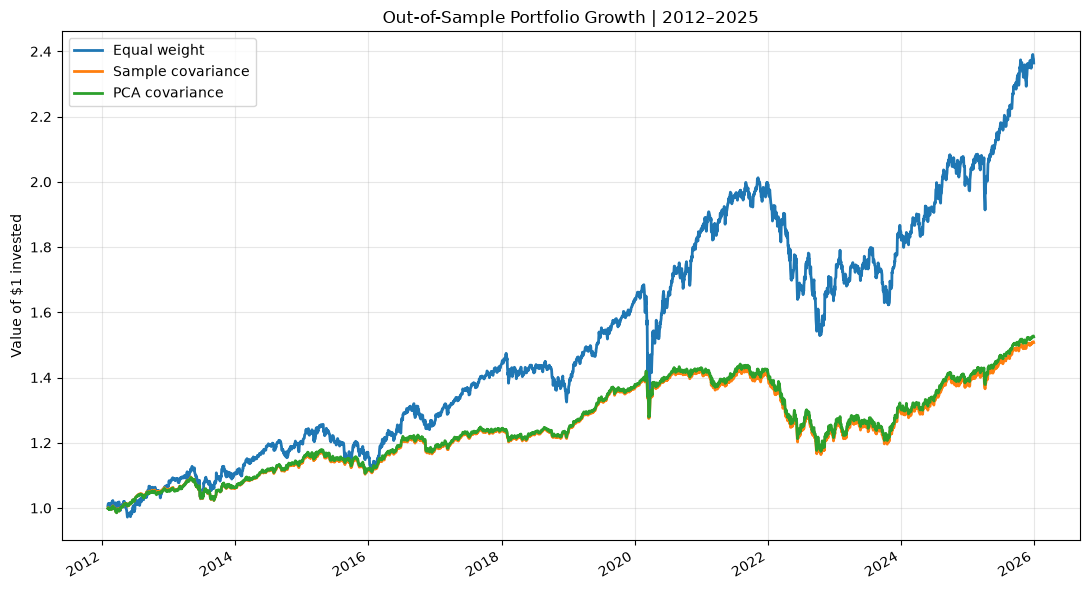

Equal weight         2.364
Sample covariance    1.507
PCA covariance       1.525
Name: Final value of $1, dtype: float64

In [49]:
portfolio_value = (1 + backtest_returns).cumprod()

ax = portfolio_value.plot(figsize=(11, 6), linewidth=2)
ax.set_title("Out-of-Sample Portfolio Growth | 2012–2025")
ax.set_ylabel("Value of $1 invested")
ax.set_xlabel("")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

display(portfolio_value.iloc[-1].round(3).rename("Final value of $1"))

In [50]:
annualized_return = (
    portfolio_value.iloc[-1] ** (252 / len(backtest_returns)) - 1
) * 100

annualized_volatility = backtest_returns.std() * np.sqrt(252) * 100

drawdown = portfolio_value / portfolio_value.cummax().clip(lower=1) - 1
maximum_drawdown = drawdown.min() * 100

results = pd.DataFrame({
    "Annualized return (%)": annualized_return,
    "Annualized volatility (%)": annualized_volatility,
    "Maximum drawdown (%)": maximum_drawdown,
})

display(results.round(2))


,Annualized return (%),Annualized volatility (%),Maximum drawdown (%)
Equal weight,6.39,9.63,-24.05
Sample covariance,3.00,5.20,-18.54
PCA covariance,3.08,5.21,-18.58


In [51]:
average_weights = pd.DataFrame({
    name: history.mean() * 100
    for name, history in weight_history.items()
})

display(average_weights.round(1))

,Equal weight,Sample covariance,PCA covariance
SPY,10.0,4.4,5.0
IWM,10.0,0.2,0.2
EFA,10.0,0.3,0.4
EEM,10.0,0.2,0.2
IEF,10.0,57.1,58.3
TLT,10.0,0.0,0.0
LQD,10.0,0.7,0.1
HYG,10.0,35.6,34.3
GLD,10.0,1.4,1.5
VNQ,10.0,0.0,0.0


In [52]:
def monthly_turnover(weight_table, asset_returns, starts):
    trades = []
    previous_end_weights = None

    for i, start in enumerate(starts):
        target = weight_table.iloc[i].reindex(asset_returns.columns)

        if previous_end_weights is not None:
            trades.append(0.5 * (target - previous_end_weights).abs().sum())

        end = starts[i + 1] if i + 1 < len(starts) else len(asset_returns)
        asset_growth = (1 + asset_returns.iloc[start:end]).prod()

        drifted = target * asset_growth
        previous_end_weights = drifted / drifted.sum()

    return pd.Series(trades, index=weight_table.index[1:])

turnover = pd.DataFrame({
    name: monthly_turnover(history, returns, rebalance_starts)
    for name, history in weight_history.items()
})

display((turnover.mean() * 100).round(2).rename("Average monthly turnover (%)"))

Equal weight         1.07
Sample covariance    2.36
PCA covariance       2.70
Name: Average monthly turnover (%), dtype: float64

In [53]:
cost_bps = 10
net_returns = backtest_returns.copy()

for name in net_returns.columns:
    for date, trade_fraction in turnover[name].items():
        cost_fraction = 2 * trade_fraction * cost_bps / 10_000
        gross_return = backtest_returns.at[date, name]
        net_returns.at[date, name] = (
            (1 - cost_fraction) * (1 + gross_return) - 1
        )

net_value = (1 + net_returns).cumprod()

cost_comparison = pd.DataFrame({
    "Gross annualized return (%)":
        (portfolio_value.iloc[-1] ** (252 / len(backtest_returns)) - 1) * 100,
    "Net annualized return (%)":
        (net_value.iloc[-1] ** (252 / len(net_returns)) - 1) * 100,
})

display(cost_comparison.round(3))

,Gross annualized return (%),Net annualized return (%)
Equal weight,6.391,6.364
Sample covariance,2.998,2.940
PCA covariance,3.084,3.017


In [54]:
yearly_volatility = (
    backtest_returns[["Sample covariance", "PCA covariance"]]
    .groupby(backtest_returns.index.year)
    .std()
    * np.sqrt(252)
    * 100
)

yearly_volatility["PCA minus sample (pp)"] = (
    yearly_volatility["PCA covariance"]
    - yearly_volatility["Sample covariance"]
)

display(yearly_volatility.round(2))

print(
    "Years PCA had lower volatility:",
    (yearly_volatility["PCA minus sample (pp)"] < 0).sum(),
    "of",
    len(yearly_volatility),
)

,Sample covariance,PCA covariance,PCA minus sample (pp)
Date,,,
2012,3.05,3.06,0.01
2013,5.04,5.04,-0.00
2014,3.20,3.20,0.00
2015,4.41,4.47,0.05
2016,4.08,4.11,0.03
2017,2.86,2.87,0.01
2018,3.08,3.08,-0.00
2019,2.99,2.99,0.00
2020,6.92,6.93,0.00


Years PCA had lower volatility: 5 of 14
